# K-Nearest Neighbors

Implementation of the K-Nearest Neighbors algorithm from scratch using only Python and NumPy.

KNN is a supervised learning algorithm used for classification and regression. In this notebook, we use it for handwritten digit classification on the MNIST dataset.

Unlike models such as Logistic Regression or Neural Networks, KNN does not learn weights during training. The `fit` method only stores the training samples and their labels. During prediction, each test image is compared with all stored training images, and the most frequent label among the `k` nearest neighbors is returned.

Dataset used: MNIST, available directly through `tensorflow.keras.datasets`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [2]:
class KNNClassifier:
    """
    K-Nearest Neighbors classifier implemented from scratch using NumPy.
    The classifier stores the training data during fitting and predicts new samples
    based on the majority class among the k nearest neighbors.
    """
    def __init__(self, k=3, distance="euclidean", p=2):
        """
        Initializes the KNN classifier.
        :param k: The number of nearest neighbors to consider.
        :type k: int
        :param distance: The distance metric to use. Options are "euclidean", "manhattan", "chebyshev", and "minkowski".
        :type distance: str
        :param p: The power parameter used for the Minkowski distance.
        :type p: int or float
        """
        self.k = k
        self.metric = distance
        self.p = p
        self.X_train = None
        self.y_train = None

    def _compute_distances(self, X_train, x):
        """
        Computes the distances between a single input sample and all training samples.
        :param X_train: The training feature matrix.
        :type X_train: np.ndarray
        :param x: A single input sample.
        :type x: np.ndarray
        :return: An array containing the distance from x to each training sample.
        :rtype: np.ndarray
        """
        diff = X_train - x

        if self.metric == "euclidean":
            return np.sqrt(np.sum(diff ** 2, axis=1))

        elif self.metric == "manhattan":
            return np.sum(np.abs(diff), axis=1)

        elif self.metric == "chebyshev":
            return np.max(np.abs(diff), axis=1)

        elif self.metric == "minkowski":
            return np.sum(np.abs(diff) ** self.p, axis=1) ** (1 / self.p)

        else:
            raise ValueError(f"Unknown distance metric: {self.metric}")

    def fit(self, X, y):
        """
        Stores the training data and labels.
        Unlike parametric models, KNN does not learn weights during training.
        The fit method only stores the training samples and their corresponding labels.
        :param X: The training feature matrix.
        :type X: np.ndarray
        :param y: The training labels.
        :type y: np.ndarray
        :return: The fitted classifier instance.
        :rtype: KNNClassifier
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

        return self

    def _predict_one(self, x):
        """
        Predicts the class label for a single input sample.
        The prediction is made by finding the k nearest training samples and
        returning the most common label among them.
        :param x: A single input sample.
        :type x: np.ndarray
        :return: The predicted class label.
        :rtype: int, float, or str
        """
        distances = self._compute_distances(self.X_train, x)

        k_indices = np.argpartition(distances, self.k - 1)[:self.k]

        k_labels = self.y_train[k_indices]

        prediction = Counter(k_labels).most_common(1)[0][0]

        return prediction

    def predict(self, X):
        """
        Predicts class labels for one or more input samples.
        If a single sample is provided as a one-dimensional array, a single
        prediction is returned. If multiple samples are provided as a two-dimensional
        array, an array of predictions is returned.
        :param X: The input sample or feature matrix.
        :type X: np.ndarray
        :return: The predicted class label or an array of predicted labels.
        :rtype: int, float, str, or np.ndarray
        """
        X = np.array(X)
        if X.ndim == 1:
            return self._predict_one(X)

        predictions = []
        for x in X:
            predictions.append(self._predict_one(x))

        return np.array(predictions)

In [3]:
X_train = np.array([

    [150, 7.0],

    [170, 7.5],

    [120, 6.0],

    [130, 6.2],

    [300, 10.0],

    [320, 10.5],

])

y_train = np.array([

    "apple",

    "apple",

    "orange",

    "orange",

    "melon",

    "melon",

])

In [4]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the data
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Flatten the 28x28 images into 784-dimensional vectors
# KNN expects shape: (n_samples, n_features)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Use a smaller subset because KNN is computationally expensive
n_train = 5000
n_test = 1000

X_train_small = X_train[:n_train]
y_train_small = y_train[:n_train]

X_test_small = X_test[:n_test]
y_test_small = y_test[:n_test]

# Train KNN
knn = KNNClassifier(k=3, distance="euclidean")
knn.fit(X_train_small, y_train_small)

# Predict
y_pred = knn.predict(X_test_small)

# Evaluate
accuracy = np.mean(y_pred == y_test_small)

print(f"Accuracy: {accuracy:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)
Accuracy: 0.9120


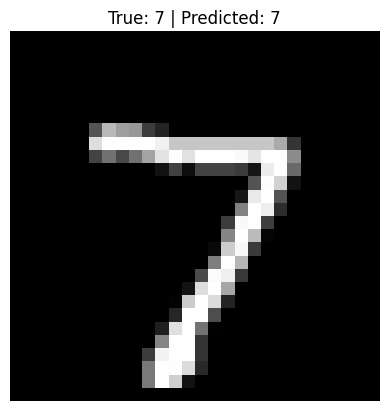

In [5]:
index = 0

plt.imshow(X_test_small[index].reshape(28, 28), cmap="gray")

plt.title(f"True: {y_test_small[index]} | Predicted: {knn.predict(X_test_small[index])}")

plt.axis("off")

plt.show()